In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/Battery_RUL.csv")

## Understanding Data

In [3]:
df.head()

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


## data description¶
* 2.8Ah NMC-LCO 18650 battery * 14ea - cycling test over 1000 times at 25°C with 0.5C charge and 1.5C discharge rate
* Cycle_Index : charge-discharge cycle number
* Discharge Time(s) : the time takes for the battery to discharge in each cycle
* Decrement 3.6-3.4V (s) : the time it takes for the battery voltage to decrease from 3.6V to 3.4V
* Max. Voltage Discharge (V) : the maximum discharge voltage observed during the discharge process
* Min. Voltage Charge (V) : the minimum discharges voltage observed during the charging process
* Time at 4.15V (s) : Discharges the time in seconds for the battery voltage to remain at 4.15V
* Time Constant Current (s) : the current time constant during the battery cycle
* Charging Time (s) : the time taken to fully charge the battery
* RUL: the remaining useful life of the battery

In [4]:
df.shape

(15064, 9)

In [5]:
data = df.copy()

In [6]:
data.head()

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15064 entries, 0 to 15063
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Cycle_Index                15064 non-null  float64
 1   Discharge Time (s)         15064 non-null  float64
 2   Decrement 3.6-3.4V (s)     15064 non-null  float64
 3   Max. Voltage Dischar. (V)  15064 non-null  float64
 4   Min. Voltage Charg. (V)    15064 non-null  float64
 5   Time at 4.15V (s)          15064 non-null  float64
 6   Time constant current (s)  15064 non-null  float64
 7   Charging time (s)          15064 non-null  float64
 8   RUL                        15064 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.0 MB


In [8]:
df.describe()

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
count,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000
mean,556.155005,4581.273960,1239.784672,3.908176,3.577904,3768.336171,5461.266970,10066.496204,554.194172
std,322.378480,33144.012077,15039.589269,0.091003,0.123695,9129.552477,25155.845202,26415.354121,322.434514
min,1.000000,8.690000,-397645.908000,3.043000,3.022000,-113.584000,5.980000,5.980000,0.000000
25%,271.000000,1169.310000,319.600000,3.846000,3.488000,1828.884179,2564.310000,7841.922500,277.000000
50%,560.000000,1557.250000,439.239471,3.906000,3.574000,2930.203500,3824.260000,8320.415000,551.000000
75%,833.000000,1908.000000,600.000000,3.972000,3.663000,4088.326500,5012.350000,8763.282500,839.000000
max,1134.000000,958320.370000,406703.768000,4.363000,4.379000,245101.117000,880728.100000,880728.100000,1133.000000


In [9]:
df.isnull().sum()

Cycle_Index                  0
Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
dtype: int64

# EDA

In [10]:
df.columns

Index(['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)',
       'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)',
       'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)',
       'RUL'],
      dtype='object')

In [11]:
print("NUMBER OF UNIQUE VALUES IN EACH COLUMN")
for col in df.columns:
    print(f"{col}---",df[col].nunique())

NUMBER OF UNIQUE VALUES IN EACH COLUMN
Cycle_Index--- 1124
Discharge Time (s)--- 10889
Decrement 3.6-3.4V (s)--- 5068
Max. Voltage Dischar. (V)--- 437
Min. Voltage Charg. (V)--- 757
Time at 4.15V (s)--- 11529
Time constant current (s)--- 3148
Charging time (s)--- 11865
RUL--- 1133


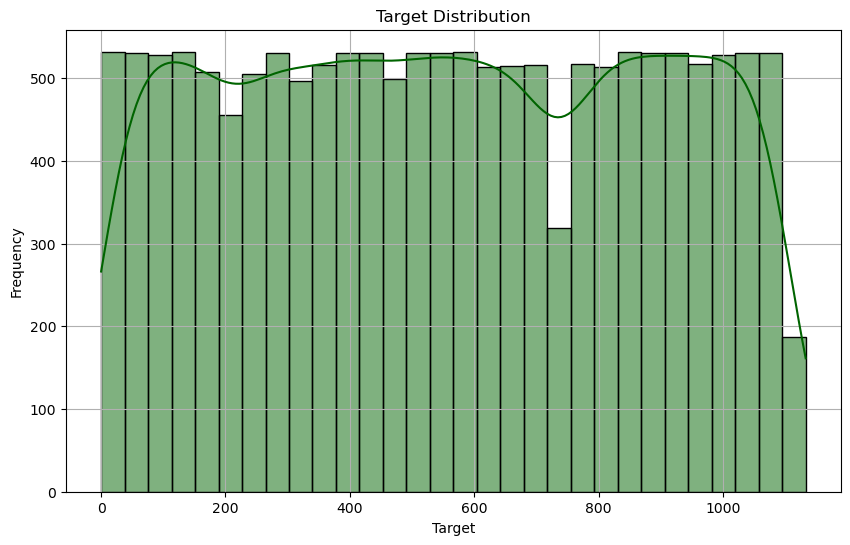

In [12]:
#target distribution
plt.figure(figsize=(10,6))
sns.histplot(df['RUL'],kde=True,bins=30,color='darkgreen')
plt.title('Target Distribution')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.grid()
plt.show()

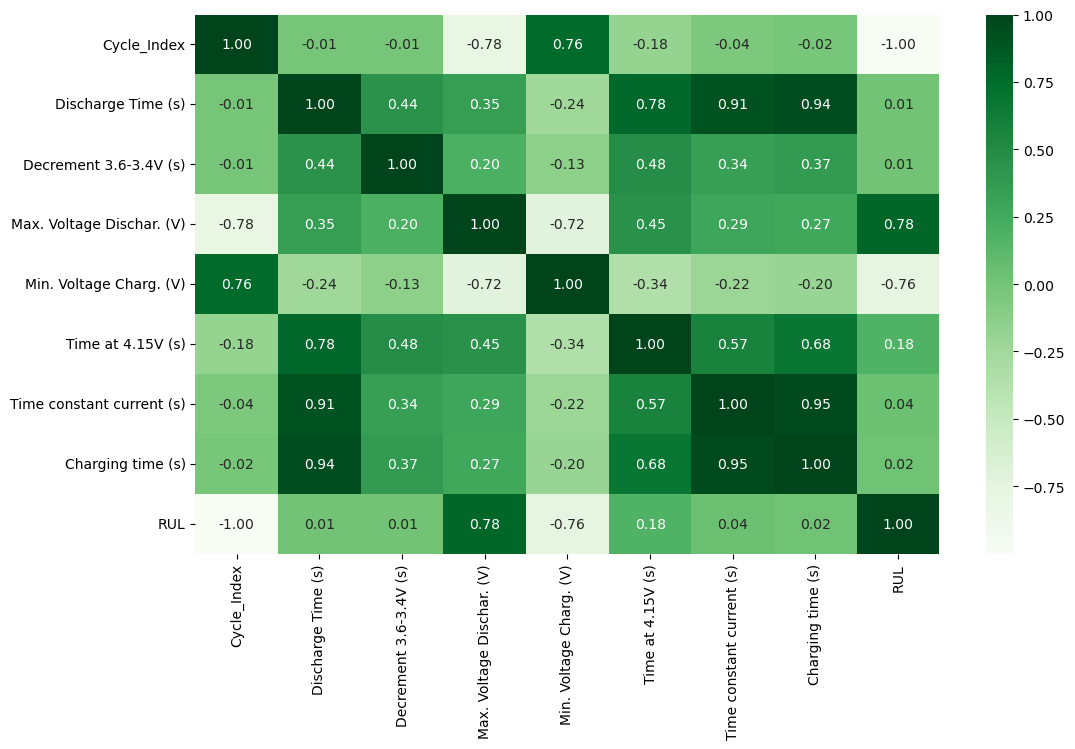

In [13]:
plt.figure(figsize = (12,7))
sns.heatmap(df.corr() , annot = True , fmt = ".2f" , cmap = "Greens")
plt.show()

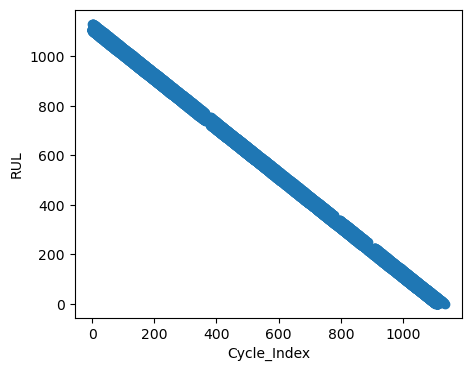

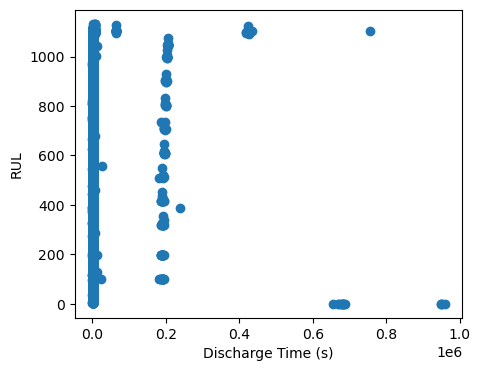

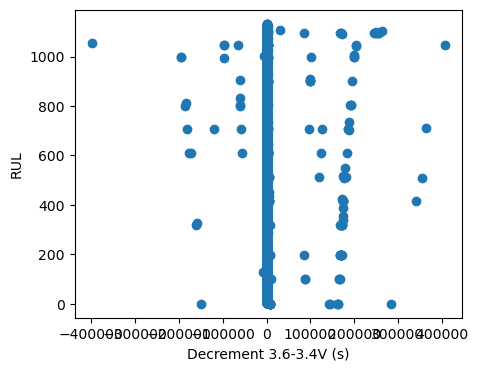

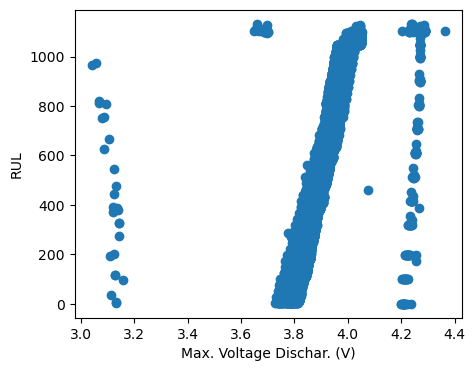

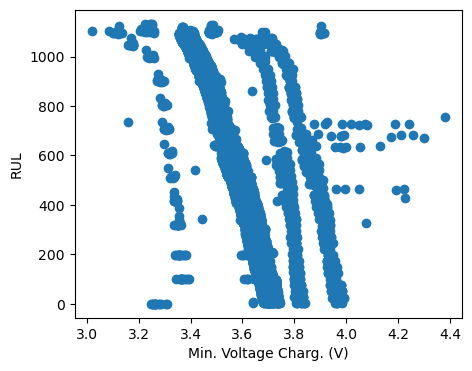

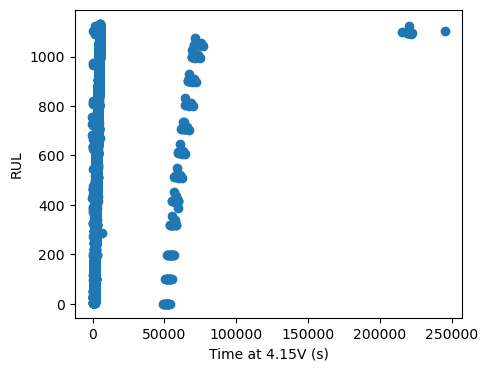

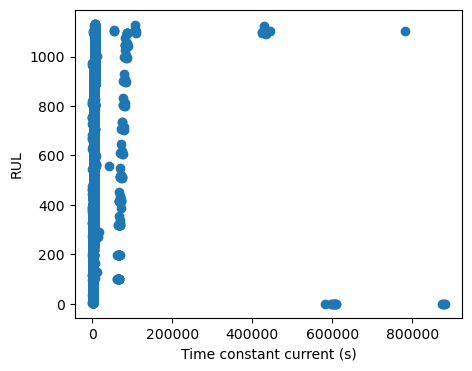

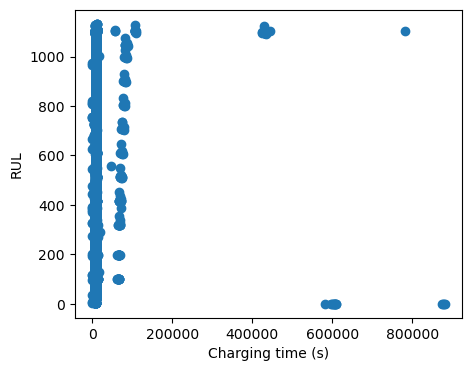

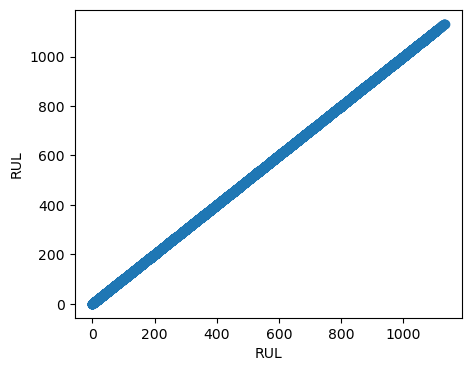

In [14]:
for col in df.columns:
    plt.figure (figsize = (5,4))
    plt.scatter(df[col],df['RUL'])
    plt.xlabel(f'{col}')
    plt.ylabel("RUL")
    plt.show()

### filtered out impossible outliers from the Discharge Time (s) column, keeping only realistic cycle durations between 500 and 2,500 seconds.

In [15]:
df = df[(df['Discharge Time (s)'] > 500) & (df['Discharge Time (s)'] < 2500)]

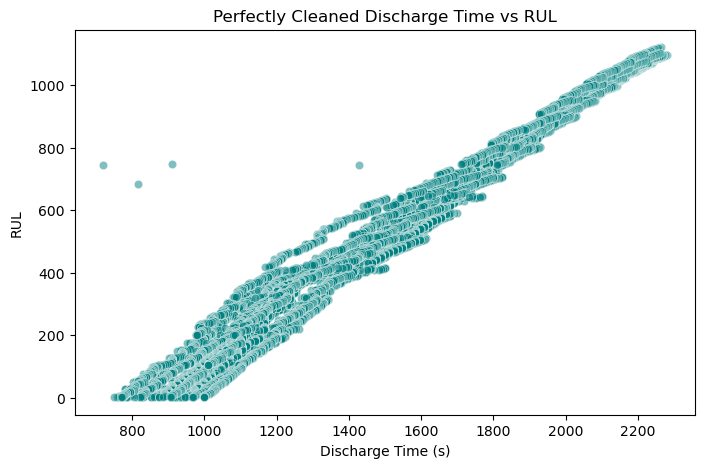

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Discharge Time (s)", y="RUL", alpha=0.5, color="teal")
plt.title("Perfectly Cleaned Discharge Time vs RUL")
plt.show()

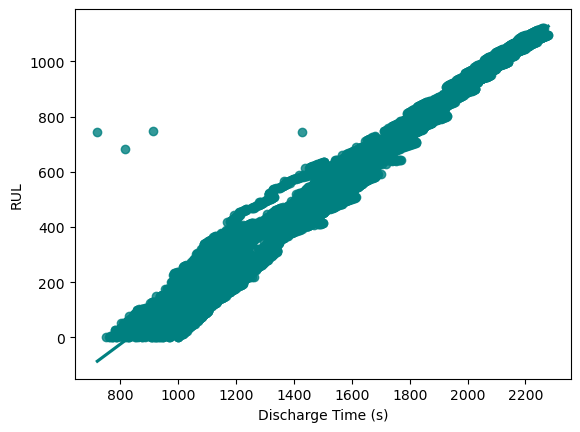

In [17]:
sns.regplot(data = df , x = df['Discharge Time (s)'] , y = df['RUL'],color = "teal")
plt.show()

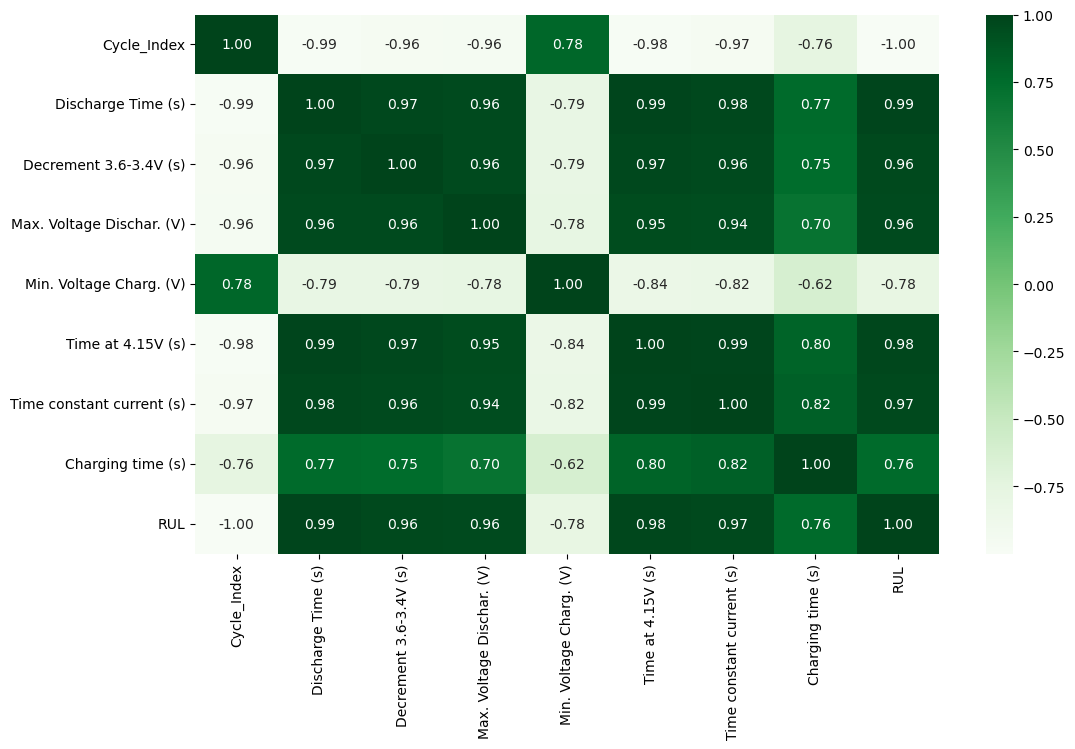

In [18]:
plt.figure(figsize = (12,7))
sns.heatmap(df.corr() , annot = True , fmt = ".2f" , cmap = "Greens")
plt.show()

## Linear reg model

In [19]:
# Droping highly redundant columns for a Linear Model
df_cleaned = df.drop(columns=['Cycle_Index', 'Decrement 3.6-3.4V (s)', 'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)'])
X = df_cleaned.drop(columns=['RUL'])
y = df_cleaned['RUL']

In [20]:
df_cleaned.head()

,Discharge Time (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),RUL
15,2261.34,4.038,3.901,1096
16,2259.46,4.042,3.373,1095
17,2256.61,4.042,3.374,1094
18,2252.83,4.043,3.374,1093
19,2250.62,4.044,3.374,1092


In [21]:
df_cleaned.shape

(14725, 4)

In [22]:
from sklearn.model_selection  import train_test_split

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [24]:
print('X_train shape : ',X_train.shape)
print('X_test shape : ',X_test.shape)
print('y_train shape : ',y_train.shape)
print('y_test shape : ', y_test.shape)

X_train shape :  (11780, 3)
X_test shape :  (2945, 3)
y_train shape :  (11780,)
y_test shape :  (2945,)


In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [27]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
model_lr = LinearRegression()

In [30]:
model_lr.fit(X_train,y_train)

LinearRegression()

In [31]:
print(model_lr.coef_)

[276.91161412  41.9798064    2.51569332]


In [32]:
print(model_lr.intercept_)

548.4196095076402


In [33]:
y_pred = model_lr.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [35]:
mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr = r2_score(y_test, y_pred)

In [37]:
print(f"Mean Absolute Error (MAE): {mae_lr:.2f} cycles")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f} cycles")
print(f"R-squared (R2 Score): {r2_lr:.4f}")

Mean Absolute Error (MAE): 36.58 cycles
Root Mean Squared Error (RMSE): 48.56 cycles
R-squared (R2 Score): 0.9769


In [38]:
print(model_lr.get_params())

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}


## Hyperparameter Tuning

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso

In [40]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge())
])

In [41]:
param_grid = [
    {
        'regressor': [LinearRegression()],
        'regressor__fit_intercept': [True, False]
    },
    {
        'regressor': [Ridge()],
        'regressor__alpha': [0.1, 1.0, 10.0, 100.0],  # Controls regularization strength
        'regressor__fit_intercept': [True, False]
    },
    {
        'regressor': [Lasso()],
        'regressor__alpha': [0.01, 0.1, 1.0, 10.0],
        'regressor__fit_intercept': [True, False]
    }
]

In [42]:
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1
)

In [43]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regressor', Ridge())]),
             n_jobs=-1,
             param_grid=[{'regressor': [LinearRegression()],
                          'regressor__fit_intercept': [True, False]},
                         {'regressor': [Ridge()],
                          'regressor__alpha': [0.1, 1.0, 10.0, 100.0],
                          'regressor__fit_intercept': [True, False]},
                         {'regressor': [Lasso()],
                          'regressor__alpha': [0.01, 0.1, 1.0, 10.0],
                          'regressor__fit_intercept': [True, False]}],
             scoring='neg_mean_absolute_error')

In [44]:
print("Best Parameters Found:")
print(grid_search.best_params_)

Best Parameters Found:
{'regressor': Lasso(), 'regressor__alpha': 0.1, 'regressor__fit_intercept': True}


In [45]:
best_model = grid_search.best_estimator_
print(f"\nBest Cross-Validated MAE: {-grid_search.best_score_:.2f} cycles")


Best Cross-Validated MAE: 36.84 cycles


In [46]:
y_pred_final = best_model.predict(X_test)

In [47]:
mae_tuned_lr = mean_absolute_error(y_test, y_pred_final)
rmse_tuned_lr = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_tuned_lr = r2_score(y_test, y_pred_final)

In [49]:
print(f"Final Mean Absolute Error (MAE): {mae_tuned_lr:.2f} cycles")
print(f"Final Root Mean Squared Error (RMSE): {rmse_tuned_lr:.2f} cycles")
print(f"Final R-squared (R2 Score): {r2_tuned_lr:.4f}")

Final Mean Absolute Error (MAE): 36.56 cycles
Final Root Mean Squared Error (RMSE): 48.56 cycles
Final R-squared (R2 Score): 0.9769


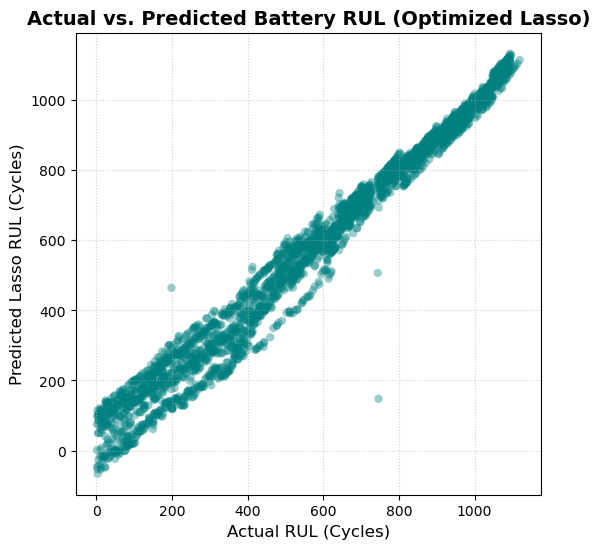

In [50]:
plt.figure(figsize=(6,6))
# Plotting the predictions
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.4, color="teal", edgecolor="none")
plt.xlabel("Actual RUL (Cycles)", fontsize=12)
plt.ylabel("Predicted Lasso RUL (Cycles)", fontsize=12)
plt.title("Actual vs. Predicted Battery RUL (Optimized Lasso)", fontsize=14, fontweight='bold')
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

## Random Forest

In [51]:
df.head()

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
15,17.0,2261.34,883.200,4.038,3.901,1949.664,2922.69,6070.11,1096
16,18.0,2259.46,883.199,4.042,3.373,5181.377,6161.38,9310.98,1095
17,19.0,2256.61,878.400,4.042,3.374,5181.375,6154.37,9296.64,1094
18,20.0,2252.83,873.601,4.043,3.374,5174.334,6147.33,9243.58,1093
19,21.0,2250.62,868.801,4.044,3.374,5160.289,6140.29,9245.53,1092


In [52]:
X_trees = df.drop(columns=['RUL', 'Cycle_Index'])
y_trees = df['RUL']

In [53]:
X_trees

,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s)
15,2261.34,883.200000,4.038,3.901,1949.664,2922.69,6070.11
16,2259.46,883.199000,4.042,3.373,5181.377,6161.38,9310.98
17,2256.61,878.400000,4.042,3.374,5181.375,6154.37,9296.64
18,2252.83,873.601000,4.043,3.374,5174.334,6147.33,9243.58
19,2250.62,868.801000,4.044,3.374,5160.289,6140.29,9245.53
...,...,...,...,...,...,...,...
15058,773.00,180.480000,3.774,3.742,922.712,1412.31,6659.62
15059,770.44,179.523810,3.773,3.742,922.775,1412.38,6678.88
15060,771.12,179.523810,3.773,3.744,915.512,1412.31,6670.38
15061,769.12,179.357143,3.773,3.742,915.513,1412.31,6637.12


In [54]:
X_train_trees,X_test_trees,y_train_trees,y_test_trees = train_test_split(X_trees,y_trees,test_size = 0.2,random_state = 42)

In [55]:
X_train_trees

,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s)
14978,852.87,213.571429,3.790,3.728,1084.352000,1628.35,6904.12
13405,1540.67,433.714286,3.929,3.551,2930.391000,3788.39,8211.56
5081,1236.00,349.203000,3.844,3.925,1771.008000,2624.99,8428.00
12587,1334.00,361.500000,3.858,3.620,2228.375000,3032.38,7988.19
4668,1836.00,571.200000,3.961,3.498,3872.320000,4796.32,8612.32
...,...,...,...,...,...,...,...
5311,960.00,251.085714,3.787,3.699,1322.343000,1916.34,7640.34
13718,1216.23,333.333333,3.861,3.634,1988.321000,2708.32,7966.59
5523,2065.97,720.000000,3.998,3.430,4664.344000,5624.34,9159.69
885,1145.89,314.400000,3.858,3.667,1787.717571,2492.29,7399.48


In [56]:
from sklearn.ensemble import RandomForestRegressor
model_rfr = RandomForestRegressor()

In [57]:
model_rfr.fit(X_train_trees,y_train_trees)

RandomForestRegressor()

In [58]:
y_pred_rfr = model_rfr.predict(X_test_trees)
print("RANDOM FOREST METRICS")
mae_rfr = mean_absolute_error(y_test_trees, y_pred_rfr)
r2_rfr = r2_score(y_test_trees, y_pred_rfr)
print(f"MAE: {mae_rfr:.2f} cycles")
print(f"R2 Score: {r2_rfr:.4f}")

RANDOM FOREST METRICS
MAE: 9.18 cycles
R2 Score: 0.9967


## SVR

In [72]:
X_train_trees = scaler.fit_transform(X_train_trees)
X_test_trees = scaler.transform(X_test_trees)

In [73]:
from sklearn.svm import SVR
model_svr = SVR(kernel='rbf', C=100, epsilon=0.1)
model_svr.fit(X_train_trees, y_train_trees)

SVR(C=100)

In [74]:
y_pred_svr = model_svr.predict(X_test_trees)

In [75]:
print("SUPPORT VECTOR REGRESSION (SVR) METRICS")
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
print(f"MAE: {mae_svr:.2f} cycles")
print(f"R2 Score: {r2_svr:.4f}")

SUPPORT VECTOR REGRESSION (SVR) METRICS
MAE: 24.96 cycles
R2 Score: 0.9827


In [76]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

In [77]:
param_distributions = {
    'C': loguniform(10, 1000),         # Explores values from 10 to 1000 exponentially
    'gamma': loguniform(0.001, 0.1),   # Explores kernel coefficients
    'epsilon': uniform(0.01, 0.2)      # Controls the margin of no-penalty error
}

In [78]:
svr_random_search = RandomizedSearchCV(
    estimator=SVR(kernel='rbf'),
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

In [79]:
svr_random_search.fit(X_train_trees, y_train_trees)

RandomizedSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000021BB0B9A520>,
                                        'epsilon': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000021BB5553D10>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000021BB0B9A3F0>},
                   random_state=42, scoring='neg_mean_absolute_error')

In [80]:
print("Best SVR Parameters Found:")
print(svr_random_search.best_params_)

Best SVR Parameters Found:
{'C': np.float64(260.70247583707646), 'epsilon': np.float64(0.014116898859160489), 'gamma': np.float64(0.08706020878304858)}


In [81]:
best_svr = svr_random_search.best_estimator_
y_pred_svr = best_svr.predict(X_test_trees)

In [82]:
print(f"OPTIMIZED SVR METRICS")
mae_op_svr = mean_absolute_error(y_test, y_pred_svr)
r2_op_svr = r2_score(y_test, y_pred_svr)
print(f"MAE: {mae_op_svr:.2f} cycles")
print(f"R2 Score: {r2_op_svr:.4f}")

OPTIMIZED SVR METRICS
MAE: 25.11 cycles
R2 Score: 0.9818


In [83]:
performance_df = pd.DataFrame({
    'Model': ['Linear Regression','Tuned Lasso' , 'Random Forest', 'Support Vector (SVR)','optimized SVR'],
    'MAE (Lower is Better)': [mae_lr,mae_tuned_lr, mae_rfr, mae_svr,mae_op_svr],
    'R2 Score (Higher is Better)': [r2_lr,r2_tuned_lr, r2_rfr, r2_svr,r2_op_svr]
})

C:\Users\ambik\AppData\Local\Temp\ipykernel_6316\1526680386.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=performance_df, x='Model', y='MAE (Lower is Better)', ax=axes[0], palette='mako')
C:\Users\ambik\AppData\Local\Temp\ipykernel_6316\1526680386.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=performance_df, x='Model', y='R2 Score (Higher is Better)', ax=axes[1], palette='viridis')


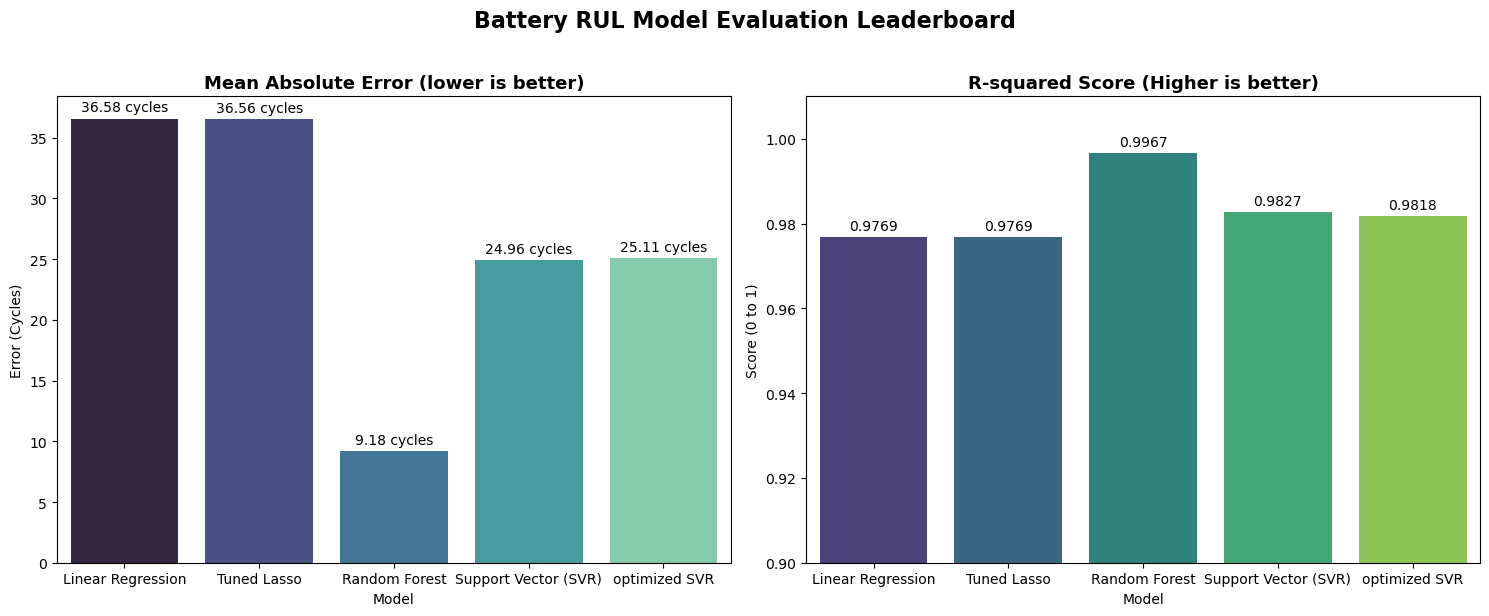

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#MAE
sns.barplot(data=performance_df, x='Model', y='MAE (Lower is Better)', ax=axes[0], palette='mako')
axes[0].set_title('Mean Absolute Error (lower is better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Error (Cycles)')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f cycles', padding=3)
#r2
sns.barplot(data=performance_df, x='Model', y='R2 Score (Higher is Better)', ax=axes[1], palette='viridis')
axes[1].set_title('R-squared Score (Higher is better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score (0 to 1)')
axes[1].set_ylim(0.9, 1.01)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.4f', padding=3)

plt.suptitle('Battery RUL Model Evaluation Leaderboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [85]:
print("Your model expects these columns in this order:")
print(X_trees.columns.tolist())

Your model expects these columns in this order:
['Discharge Time (s)', 'Decrement 3.6-3.4V (s)', 'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)', 'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)']


## testing on new data

In [86]:
custom_battery = [[
    2150.0,  # Discharge Time (s)
    1150.0,  # Decrement 3.6-3.4V (s)
    4.02,    # Max. Voltage Dischar. (V)
    3.36,    # Min. Voltage Charg. (V)
    20.0,    # Time at 4.15V (s)
    620.0,   # Time constant current (s)
    5100.0   # Charging time (s)
]]

In [87]:
new_sample = pd.DataFrame(custom_battery, columns=[
    'Discharge Time (s)', 'Decrement 3.6-3.4V (s)', 'Max. Voltage Dischar. (V)', 
    'Min. Voltage Charg. (V)', 'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)'
])

In [89]:
predicted_cycles = model_rfr.predict(new_sample)
print(f"Predicted Remaining Useful Life: {predicted_cycles[0]:.2f} cycles")

Predicted Remaining Useful Life: 1025.83 cycles


# Saving the model

In [90]:
import joblib
joblib.dump(model_rfr, 'battery_rul_champion_rf.pkl', compress=3)
print("Random Forest model saved successfully!")

Random Forest model saved successfully!
